In [1]:
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import normalize


2023-03-10 10:12:44.504360: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-03-10 10:12:46.002093: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/hubert/.local/lib/python3.10/site-packages/cv2/../../lib64:
2023-03-10 10:12:46.002172: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-03-10 10:12:52.412034: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerr

## 1) The Dataset

- Assuming you have a classification problem, is it binary, multi-class or multi-label?

- Show a few examples per class

- How many classes? 1

- How many images per class? 3200

- Train/Test sizes 0.67/0.33

- Image size? 64x64

- How are the images labeled? yes

- Dataset source(s)? DuckDuckGo images

In [2]:
def load_images(paths, labels, max_num_class):
    '''
    
    
    Arguments
        paths: list of directory paths
        lables: list of lables for images in directory
        max_num_class: maximal number of images from directory
    Returns
        images: list of pixelvalues in grayscale
        label: list of labels
    '''
    images = []
    label = []
    for i, path in enumerate(paths):
        count = 0
        for file in glob.glob("../prepareData/" + path + "/*.jpg"):
            if count >= max_num_class:
                break
            images.append(cv2.imread(file, 0))
            label.append(labels[i])
            count += 1
    
    images = np.array(images, dtype=object)
    label = np.array(label, dtype=object)
    
    return images, label

In [3]:
paths = ["black man", "black woman", "white man", "white woman", "wild boar", "wolf", "dear", "fox"]
labels = [0, 0, 0, 0, 1, 1, 1, 1]
X, y = load_images(paths, labels, 800)

In [4]:
X = X.astype("float32")
y = y.astype("bool")
X.shape, y.shape

((6258, 256, 256), (6258,))

In [10]:
#Show images
#plt.imshow(X[0]), plt.imshow(X[4000])
train_ds = [X,y]
train_ds = pd.DataFrame(train_ds)
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

/home/hubert/.local/lib/python3.10/site-packages/pandas/core/internals/construction.py:568: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  values = np.array([convert(v) for v in values])


ValueError: could not broadcast input array from shape (6258,256,256) into shape (6258,)

In [11]:
X = np.reshape(X, (X.shape[0], X.shape[1]*X.shape[2]))
X.shape, y.shape

((6258, 65536), (6258,))

In [12]:
X = normalize(X)
X[0], X[1]

(array([0.00371045, 0.0037485 , 0.0037485 , ..., 0.00477601, 0.00485212,
        0.00466184], dtype=float32),
 array([0.00517033, 0.00517033, 0.00517033, ..., 0.00517033, 0.00517033,
        0.00517033], dtype=float32))

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.33,
                                                    random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4192, 65536), (2066, 65536), (4192,), (2066,))

## 2) Baselines

- Random guess accuracy?

- Human-Level Performance accuracy?

- Multilayer Perceptron accuracy?

In [14]:
sequential = Sequential()

sequential.add(Dense(512, activation='relu'))
sequential.add(Dense(256, activation='relu'))
sequential.add(Dense(64, activation='relu'))
sequential.add(Dropout(0.2))
sequential.add(Dense(1, activation='sigmoid'))

2023-03-08 12:38:19.739822: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/hubert/.local/lib/python3.10/site-packages/cv2/../../lib64:
2023-03-08 12:38:19.745766: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2023-03-08 12:38:19.747615: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (Hubert-Ubuntu): /proc/driver/nvidia/version does not exist
2023-03-08 12:38:19.768033: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate co

In [15]:
#from keras.optimizers import Adam
#opt = Adam(learning_rate=1)
sequential.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [16]:
monitor_val_acc = EarlyStopping(monitor='val_loss', 
                                patience=5)

model_checkpoint = ModelCheckpoint('best_model.hdf5', save_best_only = True)

# Train your model and save its history
h_callback = sequential.fit(X_train, y_train, epochs = 1000,
                            batch_size = 32,
                            validation_data=(X_test, y_test),
                            callbacks=[monitor_val_acc, model_checkpoint])

2023-03-08 12:38:20.976120: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 1098907648 exceeds 10% of free system memory.


Epoch 1/1000


2023-03-08 12:38:31.110422: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 134217728 exceeds 10% of free system memory.
2023-03-08 12:38:32.216173: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 134217728 exceeds 10% of free system memory.
2023-03-08 12:38:32.775440: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 134217728 exceeds 10% of free system memory.
2023-03-08 12:38:35.272708: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 134217728 exceeds 10% of free system memory.


131/131 [==============================] - 253s 2s/step - loss: 0.6918 - accuracy: 0.5327 - val_loss: 0.7013 - val_accuracy: 0.5136
Epoch 2/1000
131/131 [==============================] - 224s 2s/step - loss: 0.6717 - accuracy: 0.5773 - val_loss: 0.6647 - val_accuracy: 0.5973
Epoch 3/1000
131/131 [==============================] - 219s 2s/step - loss: 0.6587 - accuracy: 0.6021 - val_loss: 0.6626 - val_accuracy: 0.5997
Epoch 4/1000
131/131 [==============================] - 199s 2s/step - loss: 0.6462 - accuracy: 0.6219 - val_loss: 0.6784 - val_accuracy: 0.5561
Epoch 5/1000
131/131 [==============================] - 213s 2s/step - loss: 0.6398 - accuracy: 0.6317 - val_loss: 0.6776 - val_accuracy: 0.5489
Epoch 6/1000
131/131 [==============================] - 215s 2s/step - loss: 0.6320 - accuracy: 0.6417 - val_loss: 0.6668 - val_accuracy: 0.6123
Epoch 7/1000
131/131 [==============================] - 281s 2s/step - loss: 0.6225 - accuracy: 0.6498 - val_loss: 0.6748 - val_accuracy: 0.599

65/65 [==============================] - 15s 217ms/step


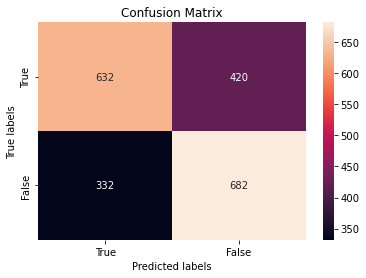

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

predicted = np.round_(sequential.predict(X_test))

conf_matrix = confusion_matrix(y_test, predicted)

ax = plt.subplot()
sns.heatmap(conf_matrix, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(['True', 'False']); ax.yaxis.set_ticklabels(['True', 'False']);

# Show the plot
plt.show()


## 3) Preprocessing

Explain all the preprocessing steps you did.

## 4) CNN architecture

In [8]:
image_size = (256, 256)
batch_size = 50

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    "../prepareData",
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    color_mode="grayscale"
)


Found 7869 files belonging to 10 classes.
Using 6296 files for training.
Using 1573 files for validation.


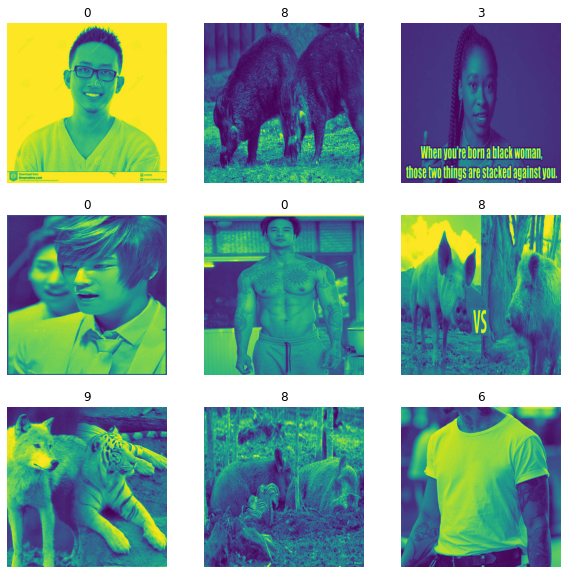

In [9]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")


In [16]:
train_ds

<BatchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [28]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1)
    ]
)


In [36]:
inputs = tf.keras.Input(shape=(256,256,1))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(128, kernel_size=3, activation='relu')(inputs)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Conv2D(64, 3, padding="same", activation='relu')(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Conv2D(32, 3, padding="same", activation='relu')(x)
x = layers.MaxPooling2D(3, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(10, activation='softmax')(x)

In [37]:
model = tf.keras.Model(inputs, output)

## 5) CNN training

- Loss function

- Optimizer (with its hyper-parameters)

- Metrics

- Learning curves

In [41]:
model.compile('adam', 'sparse_categorical_crossentropy')

In [42]:
model.fit(train_ds, validation_data=val_ds, epochs=6)

Epoch 1/6
  3/126 [..............................] - ETA: 1:33:16 - loss: 16.7820

Unsupported color conversion request


  6/126 [>.............................] - ETA: 1:38:43 - loss: 11.8704

InvalidArgumentError: Graph execution error:

jpeg::Uncompress failed. Invalid JPEG data or crop window.
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_train_function_14421]

## 6) Model performance

Metrics plots

## 7) Error analysis

Top error interpretation